In [1]:
import matplotlib.pyplot as plt
import sys
import os
import importlib

In [2]:
# Add the parent directory to the path to import src as a package
sys.path.insert(0, os.path.abspath('..'))
from src import dataloader
importlib.reload(dataloader)
from src import utils
from src import export
importlib.reload(export)
from src.export import export_to_xarray 

%matplotlib inline 
plot_flag = False

In [3]:
import xarray as xr

In [4]:
def plot_data_with_margin(multimodal_data, selected_event, time_margin, member, selected_channels):
    ev = multimodal_data.events[selected_event]
    event_start = ev['start']
    event_end = ev['start'] + ev['duration']

    recording_start = multimodal_data.data['time'].min()
    recording_end = multimodal_data.data['time'].max()

    selected_time = [
        max(recording_start, event_start - time_margin),
        min(recording_end, event_end + time_margin),
    ]
    print(f"Dyad ID: {multimodal_data.id}")
    print(f"Event '{selected_event}' starts at {event_start:.2f}s and ends at {event_end:.2f}s")
    print(f"Selected time range with ±{time_margin}s margin: {selected_time[0]:.2f}s to {selected_time[1]:.2f}s")

    time, channels_EEG, data_EEG = multimodal_data.get_signals(
        mode='EEG',
        member=member,
        selected_channels=selected_channels,
        selected_times=selected_time
    )
    print(f"Retrieved EEG data shape: {data_EEG.shape}")  # Should be (n_channels, n_samples)
    time, channels, diode_data = multimodal_data.get_signals(
                        mode='diode', 
                        selected_channels=['diode'],
                        selected_times=selected_time
                    )  
    plt.figure(figsize=(15, 3))
    for i, ch_name in enumerate(channels_EEG):
        plt.plot(time, data_EEG[:,i], label=ch_name)
    plt.plot(time, diode_data[:,0]*200, label='diode', color='k', linewidth=2)
    plt.axvline(x=event_start, color='r', linestyle='--', label='Event Start')
    plt.axvline(x=event_end, color='g', linestyle='--', label='Event End')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (µV)')
    plt.title(f'EEG Signals for Selected Channels between {selected_time[0]:.2f}s and {selected_time[1]:.2f}s during {selected_event} Event')
    plt.legend()
    plt.show()
    return 



# Select parameters

In [5]:
time_margin = 10 # seconds
member = 'ch' #'cg'
selected_modality = 'EEG' # choose 'EEG', 'ECG', 'ET' , 'IBI' or 'diode' for modality to export to xarray (diode is the reference for checking the correctnes of event slicing)
selected_channels = ['Fp1', 'Fp2',  'O1', 'O2'] # 'F7', 'F3', 'Fz', 'F4', 'F8', 'M1', 'T3', 'C3', 'Cz', 'C4', 'T4', 'M2', 'T5', 'P3', 'Pz', 'P4', 'T6',

lowcut=1.0
highcut=40.0
eeg_filter_type = 'iir' # choose 'fir' or 'iir' for EEG filtering
q=8  # decimation factor

# Load example data for one dyad

Detected events: [{'name': 'Brave', 'start': 382.1572265625, 'duration': 59.3291015625}, {'name': 'Peppa', 'start': 312.2607421875, 'duration': 59.61328125}, {'name': 'Incredibles', 'start': 242.8125, 'duration': 59.21484375}, {'name': 'Talk_1'}, {'name': 'Talk_2'}]
Applying iir filters to EEG data.
Reseting the EEG time to the start of Incredibles
No ET_event found, using EEG_events data only.
Events column created based on EEG_events and ET_event columns.
Event structure created based on events column.

Event Name                     Start (s)       Duration (s)   
Incredibles                    0.00            59.21          
Peppa                          69.45           59.60          
Brave                          139.35          59.32          

Available events: ['Incredibles', 'Peppa', 'Brave']
Dyad ID: W_003
Event 'Incredibles' starts at 0.00s and ends at 59.21s
Selected time range with ±10s margin: -10.00s to 69.21s
Retrieved EEG data shape: (10140, 4)


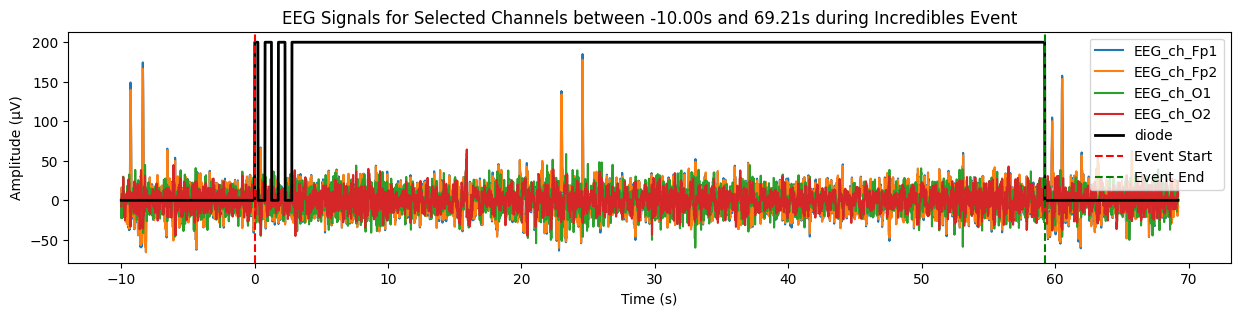

Dyad ID: W_003
Event 'Peppa' starts at 69.45s and ends at 129.05s
Selected time range with ±10s margin: 59.45s to 139.05s
Retrieved EEG data shape: (10190, 4)


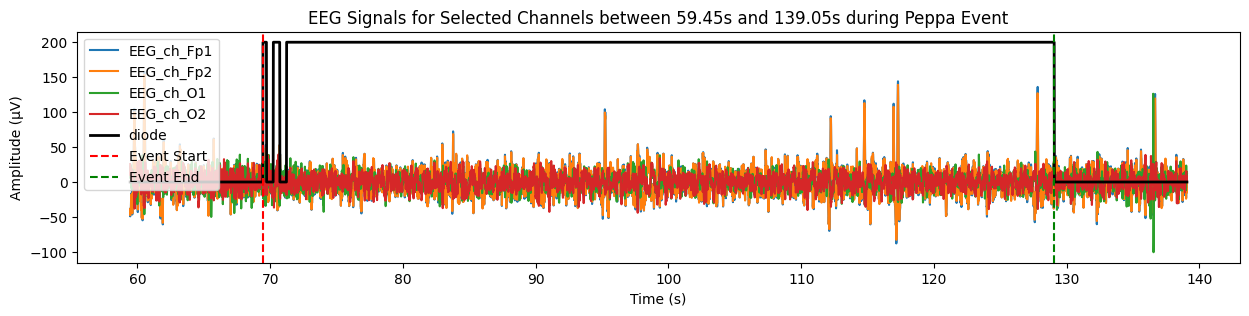

Dyad ID: W_003
Event 'Brave' starts at 139.35s and ends at 198.67s
Selected time range with ±10s margin: 129.35s to 208.67s
Retrieved EEG data shape: (10154, 4)


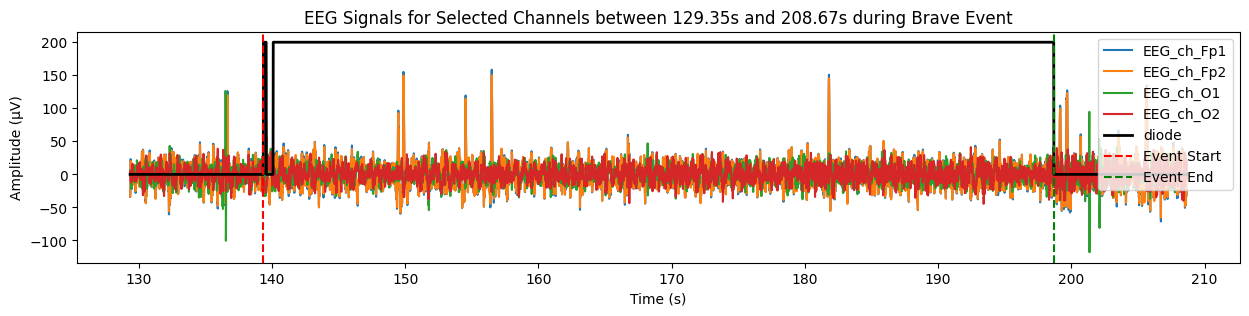

In [6]:
dyad_id = "W_003"# "W_009", "W_030"
multimodal_data = dataloader.create_multimodal_data(data_base_path = "../data", 
                                                    dyad_id = dyad_id, 
                                                    load_eeg=True, 
                                                    load_et=False, 
                                                    load_meta = True,
                                                    lowcut=lowcut, 
                                                    highcut=highcut, 
                                                    eeg_filter_type=eeg_filter_type, 
                                                    interpolate_et_during_blinks_threshold=0.3,
                                                    median_filter_size=64,
                                                    low_pass_et_order=351,
                                                    et_pos_cutoff=128,
                                                    et_pupil_cutoff=4,
                                                    pupil_model_confidence=0.9,
                                                    decimate_factor=q,
                                                    plot_flag=plot_flag)
all_events = list(multimodal_data.events.keys())
print(f"Available events: {all_events}")
for selected_event in all_events:
    plot_data_with_margin(multimodal_data, selected_event = selected_event, time_margin = time_margin, member = member, selected_channels = selected_channels)

# Get the selected data modality for a given event with a time margin on both ends 

Event 'Peppa' starts at 69.45s and ends at 129.05s
Selected time range with ±10s margin: 59.45s to 139.05s
<xarray.DataArray 'signals' (time: 10190, channel: 21)> Size: 2MB
array([[-46.09469701, -44.66132159, -33.58875733, ...,  27.25886137,
         12.06583442,  25.70216479],
       [-49.12959394, -47.517479  , -29.08203203, ...,  12.99392389,
         21.71162039,  11.45719633],
       [-45.63097162, -44.04243938, -21.45925609, ...,  15.65055313,
         14.8988497 ,  10.31616874],
       ...,
       [-13.4432561 , -14.65679346,   6.26611076, ...,  -4.08805751,
          8.37476395,   4.53650406],
       [ -2.66237625,  -6.24652757,  10.82104781, ..., -12.69957116,
         14.09201335,   6.17966633],
       [  2.61723576,  -2.07704526,  -2.60661465, ...,  -4.72528947,
         12.98320489,   7.6762198 ]], shape=(10190, 21))
Coordinates:
  * time     (time) float64 82kB -10.0 -9.992 -9.984 -9.977 ... 69.59 69.59 69.6
  * channel  (channel) <U3 252B 'Fp1' 'Fp2' 'F7' 'F3' ... 'P4' 'T

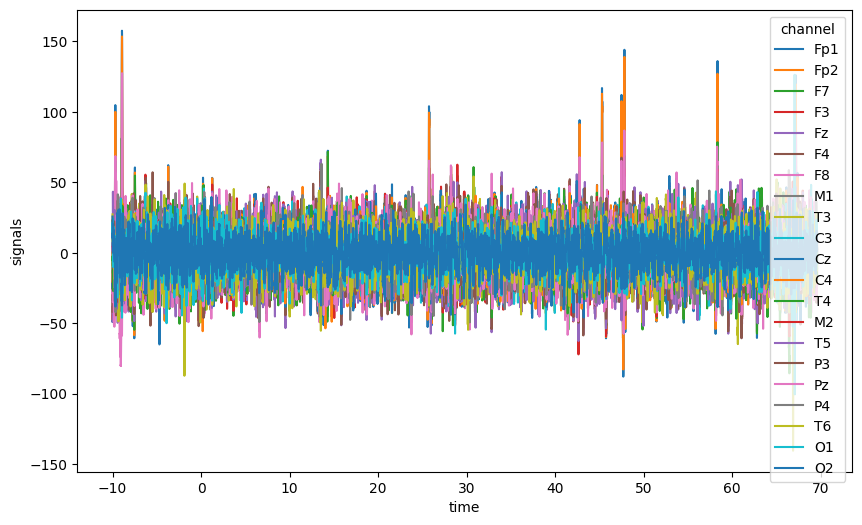

In [7]:
time_margin = 10 # seconds
selected_event =  'Peppa' #'Incredibles' 'Peppa' 'Brave' 'Talk_1' 'Talk_2'
member = 'ch' #'cg'

selected_modality = 'EEG' # choose 'EEG', 'ECG', 'ET' , 'IBI' or 'diode' for modality to export to xarray (diode is the reference for checking the correctnes of event slicing)
selected_channels = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'M1', 'T3', 'C3', 'Cz', 'C4', 'T4', 'M2', 'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2']
#selected_modality = 'ET'
#selected_channels = ['x', 'y', 'pupil', 'blinks']

#selected_modality = 'ECG'
#selected_channels = ['ECG']

#selected_modality = 'IBI'
#selected_channels = ['IBI']
#selected_modality = 'diode'
#selected_channels = ['diode']

data_EEG_xr = export_to_xarray(multimodal_data = multimodal_data, 
                               selected_event=selected_event, 
                               selected_channels=selected_channels, 
                               selected_modality=selected_modality, 
                               member=member, 
                               time_margin=time_margin)
# print the xarray DataArray to verify its structure and metadata
print(data_EEG_xr)



# plot the retrieved EEG data using xarray's built-in plotting
plt.figure(figsize=(10, 6))
data_EEG_xr.plot.line(x='time', hue='channel')
plt.show()


In [8]:
data_EEG_xr

<xarray.DataArray 'signals' (time: 10190, channel: 21)> Size: 2MB
array([[-46.09469701, -44.66132159, -33.58875733, ...,  27.25886137,
         12.06583442,  25.70216479],
       [-49.12959394, -47.517479  , -29.08203203, ...,  12.99392389,
         21.71162039,  11.45719633],
       [-45.63097162, -44.04243938, -21.45925609, ...,  15.65055313,
         14.8988497 ,  10.31616874],
       ...,
       [-13.4432561 , -14.65679346,   6.26611076, ...,  -4.08805751,
          8.37476395,   4.53650406],
       [ -2.66237625,  -6.24652757,  10.82104781, ..., -12.69957116,
         14.09201335,   6.17966633],
       [  2.61723576,  -2.07704526,  -2.60661465, ...,  -4.72528947,
         12.98320489,   7.6762198 ]], shape=(10190, 21))
Coordinates:
  * time     (time) float64 82kB -10.0 -9.992 -9.984 -9.977 ... 69.59 69.59 69.6
  * channel  (channel) <U3 252B 'Fp1' 'Fp2' 'F7' 'F3' ... 'P4' 'T6' 'O1' 'O2'
Attributes:
    dyad_id:         W_003
    who:             ch
    sampling_freq:   128.0
    event_name:      Peppa
    event_start:     0.0
    event_duration:  59.6015625
    time_margin_s:   10.0
    metadata_json:   {"notes": NaN, "child_info": {"age_months": 51.0, "group...